## EDA Summary & Modeling Decisions

| Finding | Decision | Reason |
|---|---|---|
| SalePrice skewness = 1.88 | Apply log1p transform to target | Reduces skew to 0.12, satisfies linear regression assumptions |
| GarageCars / GarageArea correlation = 0.88 | Drop GarageArea | Redundant signal, GarageCars retained (slightly higher correlation with target) |
| TotalBsmtSF / 1stFlrSF correlation = 0.82 | Drop 1stFlrSF | Redundant signal, TotalBsmtSF retained |
| 2 GrLivArea outliers (large area, low price) | Remove both rows | Likely non-standard sales that would distort model learning |

**Top predictors identified:** OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64)
These features should rank highly in final model importance — a useful sanity check.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/processed/housing_processed.csv')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Question 1 —  Does SalePrice need a log transform?

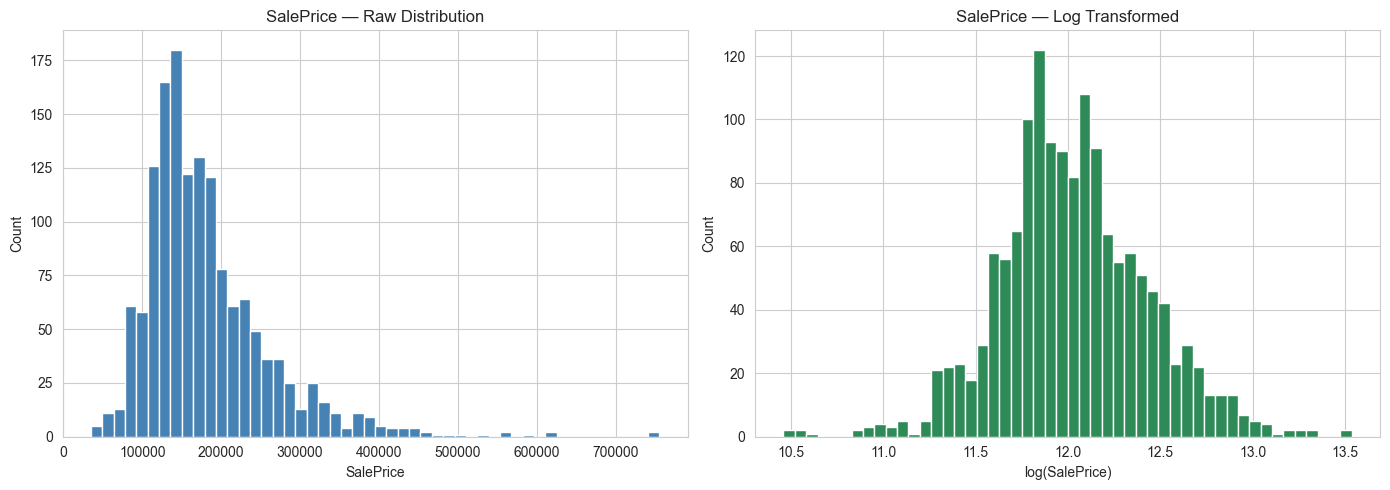

Raw skewness:     1.8829
Log skewness:     0.1213


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw SalePrice
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Raw Distribution')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

# Log-transformed SalePrice
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice — Log Transformed')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Skewness values
print(f"Raw skewness:     {df['SalePrice'].skew():.4f}")
print(f"Log skewness:     {np.log1p(df['SalePrice']).skew():.4f}")

### Insight
SalePrice is right-skewed (skewness > 1), meaning a small number of expensive 
houses pull the distribution. Linear regression assumes normally distributed 
errors, so we apply log1p() to the target variable to reduce skew and better 
satisfy model assumptions. All regression metrics will be computed in log space 
and converted back for interpretation.

### Question 2 — Which features correlate most with SalePrice?

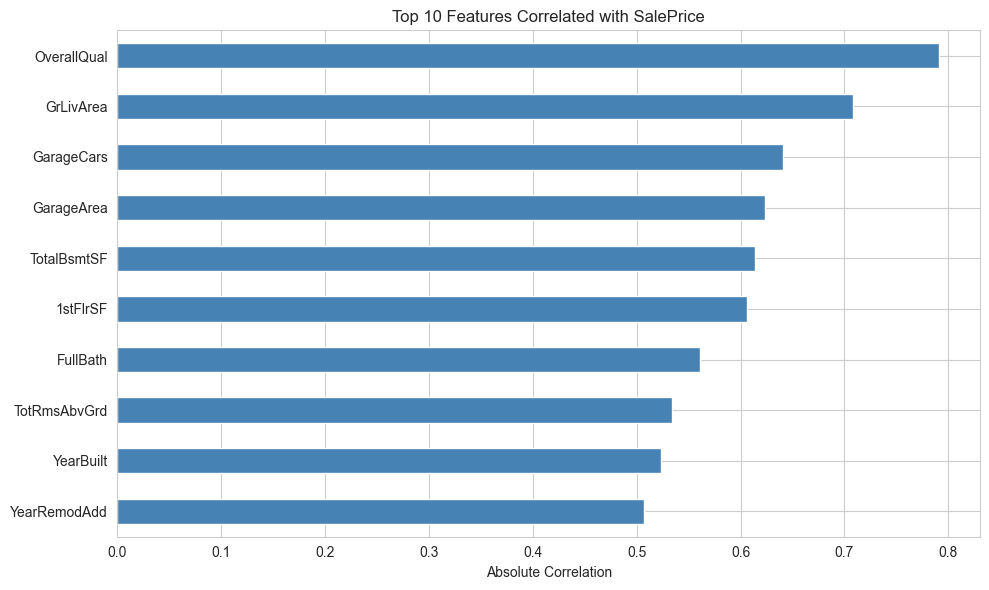

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [4]:
# Numeric correlations with SalePrice
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].drop('SalePrice')
top_corr = correlations.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_corr.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Features Correlated with SalePrice')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

print(top_corr)

### Insight
OverallQual, GrLivArea, and GarageCars show the strongest correlations with 
SalePrice. These features will be prioritized during feature engineering and 
serve as a sanity check — if our model doesn't weight these heavily, something 
is wrong.

### Question 3 — Are top features collinear with each other?

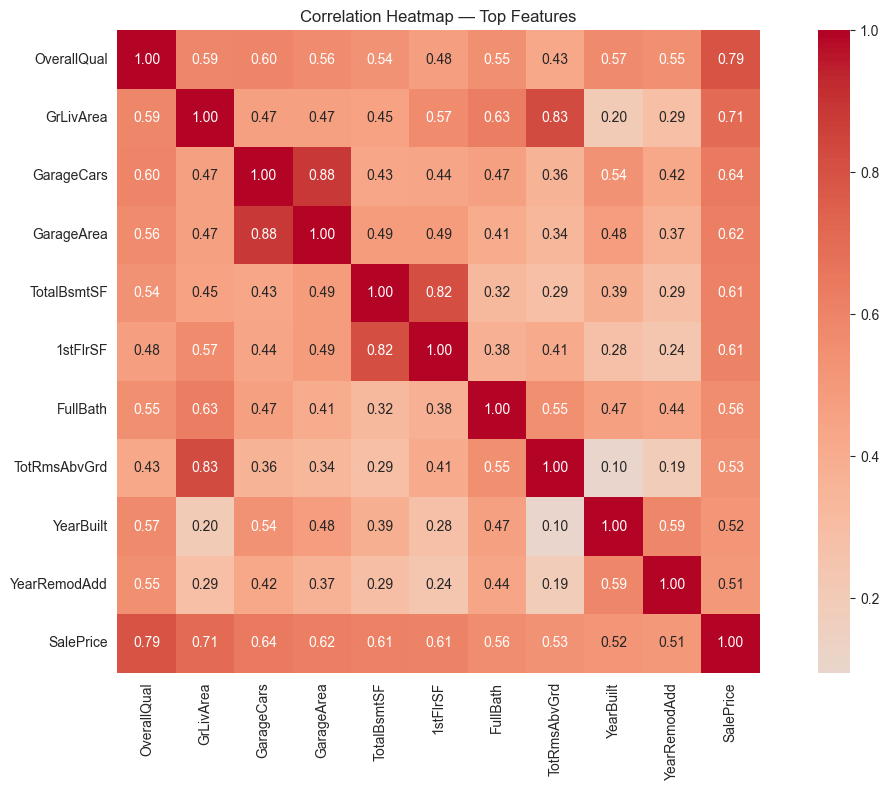

In [5]:
top_features = top_corr.index.tolist() + ['SalePrice']

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap — Top Features')
plt.tight_layout()
plt.show()

### Insight
GarageCars and GarageArea are highly correlated with each other (r > 0.85), 
meaning they carry redundant information. We retain GarageCars as it showed 
slightly stronger correlation with SalePrice. This multicollinearity is one 
reason Ridge/Lasso regularization is preferred over plain Linear Regression 
for this dataset.

### Question 4 — Key feature distributions

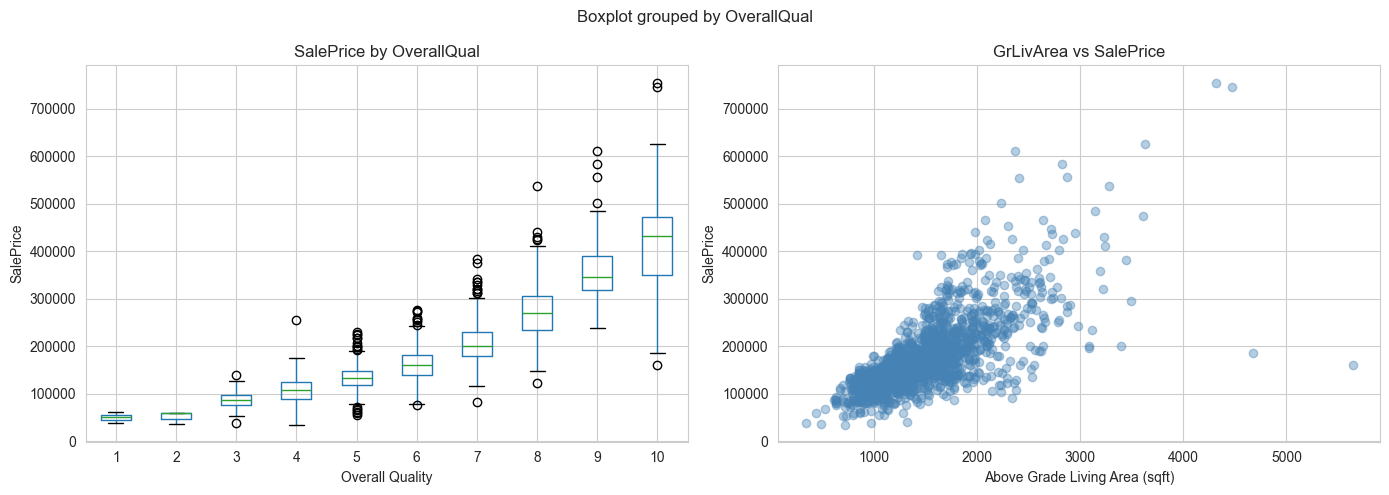

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OverallQual vs SalePrice
df.boxplot(column='SalePrice', by='OverallQual', ax=axes[0])
axes[0].set_title('SalePrice by OverallQual')
axes[0].set_xlabel('Overall Quality')
axes[0].set_ylabel('SalePrice')

# GrLivArea vs SalePrice
axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue')
axes[1].set_title('GrLivArea vs SalePrice')
axes[1].set_xlabel('Above Grade Living Area (sqft)')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

### Insight
OverallQual shows a near-monotonic relationship with SalePrice — each quality 
tier commands a meaningfully higher price. GrLivArea shows a strong positive 
linear relationship with two visible outliers (large area, low price) that may 
warrant investigation before modeling.

In [7]:
# Drop redundant collinear features identified in heatmap
df = df.drop(columns=['GarageArea', '1stFlrSF'])

# Remove GrLivArea outliers — large area, unusually low price
outlier_idx = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)].index
print(f"Removing {len(outlier_idx)} outlier(s): index {list(outlier_idx)}")
df = df.drop(index=outlier_idx)

print(f"Dataset shape after cleaning: {df.shape}")

Removing 2 outlier(s): index [523, 1298]
Dataset shape after cleaning: (1458, 75)
